In [1]:
import numpy as np

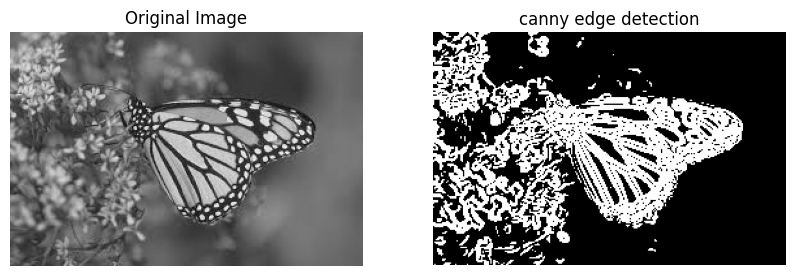

In [2]:
# input image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read image (grayscale)
img = cv2.imread(r'C:\BDA\digital image processing\Dip_class\dip_img\images_butterfly.jfif', 0)

# 1. Gaussian Blur
kernel = np.array([
    [1, 0, 1],
    [2, 0, 2],
    [3, 0, 1]
]) / 16

h, w = img.shape
smooth = np.zeros((h-2, w-2))

for i in range(h-2):
    for j in range(w-2):
        smooth[i,j] = np.sum(img[i:i+3, j:j+3] * kernel)

# 2. Sobel Gradient
Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
Ky = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

h, w = smooth.shape
G = np.zeros((h-2, w-2))
theta = np.zeros((h-2, w-2))

for i in range(h-2):
    for j in range(w-2):
        gx = np.sum(smooth[i:i+3, j:j+3] * Kx)
        gy = np.sum(smooth[i:i+3, j:j+3] * Ky)
        G[i,j] = np.sqrt(gx**2 + gy**2)
        theta[i,j] = np.arctan2(gy, gx)

# 3. Simple Threshold
threshold = 50
edges = np.zeros_like(G)

for i in range(G.shape[0]):
    for j in range(G.shape[1]):
        if G[i,j] > threshold:
            edges[i,j] = 255


# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("canny edge detection")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()
